# Below we import packages we may need

In [1]:
import time
import sklearn
from sklearn.metrics import f1_score
from sklearn.metrics import auc
from sklearn.metrics import accuracy_score
from sklearn.metrics import average_precision_score
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from numpy import mean
from numpy import std
from sklearn.metrics import auc
from sklearn.metrics import make_scorer
from scipy import stats
from sklearn.metrics import roc_auc_score, precision_recall_curve, confusion_matrix, accuracy_score, auc, roc_curve
from sklearn.linear_model import LassoCV
from scipy import interp

<a class="anchor" id="Data"></a>
Below we import the data.

In [4]:
annotated_mz_data = pd.read_csv("C:/PhD rotation 1/New Analysis Annotated mz/annotated_mz_only_post_processed_maplet_data.csv", index_col = 0)
annotated_mz_data

,341.3045359,688.1566289,480.3106071,452.2779431,137.0476093,266.1729689,275.0078481,551.3492125,343.1310698,988.5106837,...,497.2887359,522.352938,517.3715465,519.2700787,268.1195442,361.1697371,Group,Organism,date_measured,batch_measured
CARB_220421_0001,0.235379,1.255321,-0.743633,-0.451378,-0.735257,0.299373,0.487887,-0.986562,0.330911,-0.600910,...,-0.050445,-0.445337,0.862473,0.225198,0.195512,0.410076,CRE,Escherichia coli,apr21,apr21
CARB_220421_0002,0.302080,0.660567,-0.628927,0.204759,-1.734406,-0.344743,-1.674753,-0.423016,0.102218,0.417236,...,0.794827,0.220338,0.373972,0.282055,0.333397,-0.125571,CRE,Enterobacter cloacae,apr21,apr21
CARB_220421_0003,-1.162677,0.023574,-0.819531,-0.349414,-1.408124,0.422816,-0.424128,-0.797650,-1.337279,-0.055619,...,0.592715,-0.186625,1.203281,0.514182,0.197211,0.384633,CRE,Klebsiella pneumoniae,apr21,apr21
CARB_220421_0004,-0.081062,0.785580,-2.157372,-1.714977,-1.424713,-0.197547,-0.240823,-0.608056,0.326369,0.888960,...,-0.041695,-0.431125,1.475143,0.326514,0.015376,-0.135694,CRE,Klebsiella pneumoniae,apr21,apr21
CARB_220421_0005,0.158468,1.086008,-2.315403,-1.202203,-0.033887,0.055588,1.091046,-2.002347,0.594032,0.697582,...,0.019417,-0.877367,1.926909,-0.133431,-0.162075,-0.317338,CRE,Klebsiella pneumoniae,apr21,apr21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CARB_220427_1065,-0.586130,-1.675135,0.457437,1.047182,1.004619,-0.322823,0.438064,-0.907827,0.606538,-0.640901,...,-0.132483,-0.271630,-0.609894,-0.119328,-0.169864,0.168971,CRE,Klebsiella pneumoniae,apr27,apr25_27
CARB_220427_1090,-1.744303,-0.207907,1.716507,1.087543,1.066645,0.438027,-0.342687,0.617194,-0.472748,-2.520532,...,0.446995,-0.484318,-0.254279,0.312930,0.264202,1.229598,CSE,Klebsiella pneumoniae,apr27,apr25_27
CARB_220427_1100,0.825350,1.079930,-0.816730,-0.876715,-1.749845,0.950413,-2.605379,0.890565,-2.061110,0.606860,...,-0.768276,-0.035163,0.302748,-0.694387,-0.524554,-0.034586,CSE,Escherichia coli,apr27,apr25_27
CARB_220427_1980,-1.438140,1.118891,0.855119,0.799500,-0.651932,-0.974634,0.048687,1.707099,0.814822,0.514977,...,0.688815,0.991651,1.294649,0.443743,0.465036,-1.296725,CRE,Escherichia coli,apr27,apr25_27


Below we look at the number of CRE and CSE for every species.

In [5]:
cf_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Citrobacter freundii']
cf_data_cre = cf_data[cf_data['Group'] == 'CRE']
print(len(cf_data_cre))
cf_data_cse = cf_data[cf_data['Group'] == 'CSE']
print(len(cf_data_cse))

ec_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Enterobacter cloacae']
ec_data_cre = ec_data[ec_data['Group'] == 'CRE']
print(len(ec_data_cre))
ec_data_cse = ec_data[ec_data['Group'] == 'CSE']
print(len(ec_data_cse))

ecoli_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Escherichia coli']
ecoli_data_cre = ecoli_data[ecoli_data['Group'] == 'CRE']
print(len(ecoli_data_cre))
ecoli_data_cse = ecoli_data[ecoli_data['Group'] == 'CSE']
print(len(ecoli_data_cse))

ka_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Klebsiella aerogenes']
ka_data_cre = ka_data[ka_data['Group'] == 'CRE']
print(len(ka_data_cre))
ka_data_cse = ka_data[ka_data['Group'] == 'CSE']
print(len(ka_data_cse))

ko_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Klebsiella oxytoca']
ko_data_cre = ko_data[ko_data['Group'] == 'CRE']
print(len(ko_data_cre))
ko_data_cse = ko_data[ko_data['Group'] == 'CSE']
print(len(ko_data_cse))

kp_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Klebsiella pneumoniae']
kp_data_cre = kp_data[kp_data['Group'] == 'CRE']
print(len(kp_data_cre))
kp_data_cse = kp_data[kp_data['Group'] == 'CSE']
print(len(kp_data_cse))

pm_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Proteus mirabilis']
pm_data_cre = pm_data[pm_data['Group'] == 'CRE']
print(len(pm_data_cre))
pm_data_cse = pm_data[pm_data['Group'] == 'CSE']
print(len(pm_data_cse))

sm_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Serratia marcescens']
sm_data_cre = sm_data[sm_data['Group'] == 'CRE']
print(len(sm_data_cre))
sm_data_cse = sm_data[sm_data['Group'] == 'CSE']
print(len(sm_data_cse))

3
4
31
6
42
47
4
3
4
3
114
13
4
7
8
4


# KP modeling

C:\Users\nicky\AppData\Local\Temp\ipykernel_504\1072363187.py:45: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  precisions_kp.append(interp(mean_recall_kp, recall[::-1], precision[::-1]))  # Reverse precision and recall
C:\Users\nicky\AppData\Local\Temp\ipykernel_504\1072363187.py:68: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs_kp.append(interp(mean_fpr_kp, fpr_kp, tpr_kp))  # Interpolate TPRs at common FPR points
C:\Users\nicky\AppData\Local\Temp\ipykernel_504\1072363187.py:45: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  precisions_kp.append(interp(mean_recall_kp, recall[::-1], precision[::-1]))  # Reverse precision and recall
C:\Users\nicky\AppData\Local\Temp\ipykernel_504\1072363187.py:68: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.inte

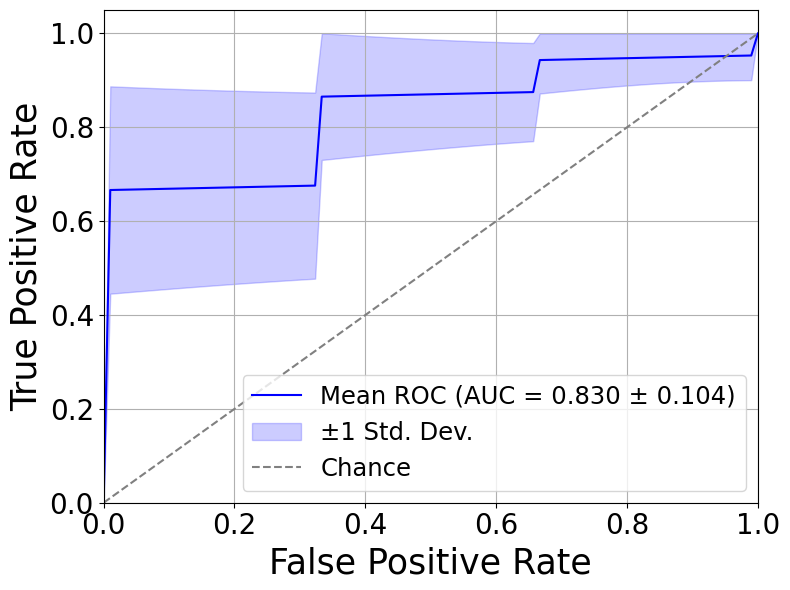

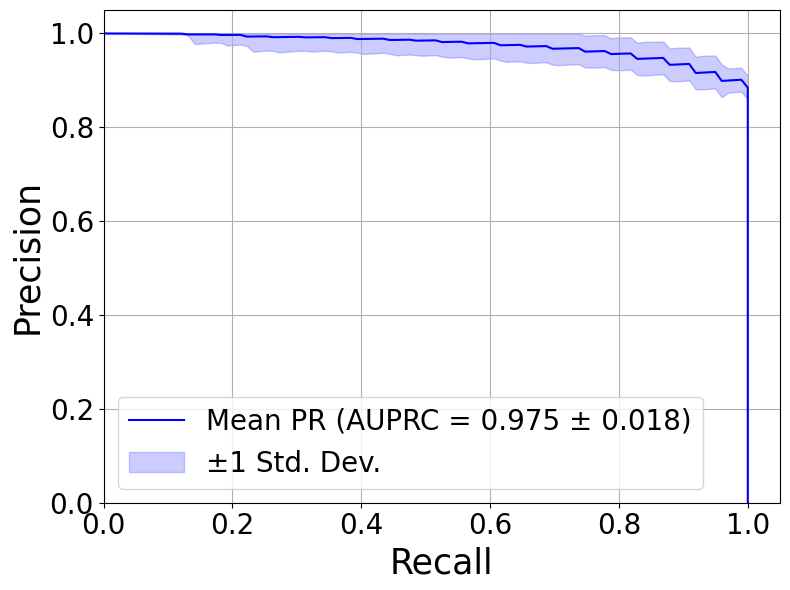

In [6]:
# Assuming your data is in X (features) and y (labels)
X = kp_data.iloc[:, :len(kp_data.columns) - 4]  # Feature data
y = pd.Series(np.where(kp_data['Group'] == 'CRE', 1, 0))  # phenotype data

# To store all metrics
results = {
    'AUC': [],
    'AUPRC': [],
    'Sensitivity': [],
    'Specificity': [],
    'PPV': [],
    'NPV': [],
    'Accuracy': []
}

# For ROC curve plotting
tprs_kp = []  # Store TPR values (true positive rates) for each split
aucs_kp = []  # Store AUC values for each split
mean_fpr_kp = np.linspace(0, 1, 100)  # Common FPR points for interpolation

# For Precision-Recall curve plotting
precisions_kp = []  # Store interpolated precision values for each split
mean_recall_kp = np.linspace(0, 1, 100)  # Common recall points for interpolation
auprcs_kp = []  # Store AUPRC values for each split

for i in range(300):
    # 80/20 train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=i)

    # 5-fold LassoCV on training set
    lasso_cv = LassoCV(cv=5, max_iter=5000).fit(X_train, y_train)
    
    # Predict probabilities on test set
    y_pred_proba = lasso_cv.predict(X_test)
    y_pred = np.where(y_pred_proba > 0.5, 1, 0)
    
    # Calculate AUC
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    # Calculate AUPRC (Area Under Precision-Recall Curve)
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    auprc_score = auc(recall, precision)
 
    # Interpolate precision values to common recall points
    precisions_kp.append(interp(mean_recall_kp, recall[::-1], precision[::-1]))  # Reverse precision and recall
    auprcs_kp.append(auprc_score)

    # Confusion matrix metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    sensitivity = tp / (tp + fn)  # Recall
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp) if tp + fp > 0 else 0  # Precision
    npv = tn / (tn + fn) if tn + fn > 0 else 0
    accuracy = accuracy_score(y_test, y_pred)

    # Append to results
    results['AUC'].append(auc_score)
    results['AUPRC'].append(auprc_score)
    results['Sensitivity'].append(sensitivity)
    results['Specificity'].append(specificity)
    results['PPV'].append(ppv)
    results['NPV'].append(npv)
    results['Accuracy'].append(accuracy)

    # ROC curve calculation
    fpr_kp, tpr_kp, _ = roc_curve(y_test, y_pred_proba)
    tprs_kp.append(interp(mean_fpr_kp, fpr_kp, tpr_kp))  # Interpolate TPRs at common FPR points
    tprs_kp[-1][0] = 0.0  # Ensure TPR starts at 0
    aucs_kp.append(auc_score)  # Store AUC for this split

# Calculate average and standard deviation (uncertainty) for the metrics
final_results = {metric: {'mean': np.mean(values), 'std': np.std(values)} for metric, values in results.items()}

# Step 5: Compute the average ROC curve and plot with ±1 standard deviation
mean_tpr_kp = np.mean(tprs_kp, axis=0)
mean_tpr_kp[-1] = 1.0  # Ensure the last TPR is 1
mean_auc_kp = np.mean(aucs_kp)
std_auc_kp = np.std(aucs_kp)
std_tpr_kp = np.std(tprs_kp, axis=0)

# Step 6: Compute the average PR curve and plot with ±1 standard deviation
mean_precision_kp = np.mean(precisions_kp, axis=0)
mean_auprc_kp = np.mean(auprcs_kp)
std_auprc_kp = np.std(auprcs_kp)
std_precision_kp = np.std(precisions_kp, axis=0)

# Plot the ROC curve with shaded standard deviation area
plt.figure(figsize=(8, 6))
plt.plot(mean_fpr_kp, mean_tpr_kp, color='b', label=r'Mean ROC (AUC = {:.3f} ± {:.3f})'.format(mean_auc_kp, std_auc_kp))

# Plot the standard deviation as a shaded area
tpr_upper_kp = np.minimum(mean_tpr_kp + std_tpr_kp, 1)
tpr_lower_kp = np.maximum(mean_tpr_kp - std_tpr_kp, 0)
plt.fill_between(mean_fpr_kp, tpr_lower_kp, tpr_upper_kp, color='b', alpha=0.2, label=r'±1 Std. Dev.')

# Add labels and titles
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.xlabel('False Positive Rate', fontsize = 25)
plt.ylabel('True Positive Rate', fontsize = 25)
plt.legend(loc="lower right", fontsize = 17.5)
plt.grid(True)
plt.tight_layout()
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/roc_curve_with_mean_and_std_cre_vs_cse_kp.png", bbox_inches = 'tight')
# Show the plot
plt.show()

# Add value to be in plot at (1, 0)
mean_recall_kp = np.append(mean_recall_kp, 1)
mean_precision_kp = np.append(mean_precision_kp, 0)
# Add value to std
std_precision_kp = np.insert(std_precision_kp, 0, 0)

# Make figure
plt.figure(figsize=(8, 6))

# Plot for Precision-Recall Curve
plt.plot(mean_recall_kp, mean_precision_kp, color='b', label=r'Mean PR (AUPRC = {:.3f} ± {:.3f})'.format(mean_auprc_kp, std_auprc_kp))

# Plot the standard deviation as a shaded area for Precision-Recall
precision_upper_kp = np.minimum(mean_precision_kp + std_precision_kp, 1)
precision_lower_kp = np.maximum(mean_precision_kp - std_precision_kp, 0)
plt.fill_between(mean_recall_kp, precision_lower_kp, precision_upper_kp, color='b', alpha=0.2, label=r'±1 Std. Dev.')

# Add labels and titles for PR
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.xlabel('Recall', fontsize = 25)
plt.ylabel('Precision', fontsize = 25)
plt.legend(loc="lower left", fontsize = 20)
plt.grid(True)
# Show the plot
plt.tight_layout()
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/auprc_curve_with_mean_and_std_cre_vs_cse_kp.png", bbox_inches = 'tight')
plt.show()

In [7]:
final_results

{'AUC': {'mean': 0.8299275362318841, 'std': 0.10377993111425443},
 'AUPRC': {'mean': 0.9746387066641478, 'std': 0.017921473106256646},
 'Sensitivity': {'mean': 0.9981159420289855, 'std': 0.011347927887451275},
 'Specificity': {'mean': 0.0022222222222222222, 'std': 0.027125679146074895},
 'PPV': {'mean': 0.8846459866220738, 'std': 0.0031587119858935623},
 'NPV': {'mean': 0.006666666666666667, 'std': 0.08137703743822466},
 'Accuracy': {'mean': 0.8832051282051284, 'std': 0.010555728570504965}}

### Fitting on all data to see what biomarkers remain 

In [8]:
# Feature names (column names of the DataFrame)
feature_names_kp = kp_data.iloc[:, :len(kp_data.columns) - 4].columns

# 5-fold LassoCV on training set
lasso_cv_kp_all_data = LassoCV(cv=5, max_iter = 5000).fit(kp_data.iloc[:, :len(kp_data.columns) - 4], pd.Series(np.where(kp_data['Group'] == 'CRE', 1, 0)))

# Get the coefficients after Lasso regularization
lasso_coefficients_kp_all_data = lasso_cv_kp_all_data.coef_

# Find the features with non-zero coefficients
# Create a DataFrame for non-zero coefficients
# Filter out the features with non-zero coefficients
remaining_features_kp = feature_names_kp[lasso_coefficients_kp_all_data != 0]
remaining_coefficients_kp = lasso_coefficients_kp_all_data[lasso_coefficients_kp_all_data != 0]

# Create a DataFrame with the selected features and their corresponding beta coefficients
feature_coeff_df_kp = pd.DataFrame({
    'Feature': remaining_features_kp,
    'Beta Coefficient': remaining_coefficients_kp
})

feature_coeff_df_kp

,Feature,Beta Coefficient
0,254.100118,0.042221
1,786.1647168,-0.015014
2,1020.369159,-0.013665
3,237.075651,0.048948
4,362.2677346,0.002593


Below we create the boxplots for the remaining metabolites from the lasso model for Klebsiella pneumoniae.

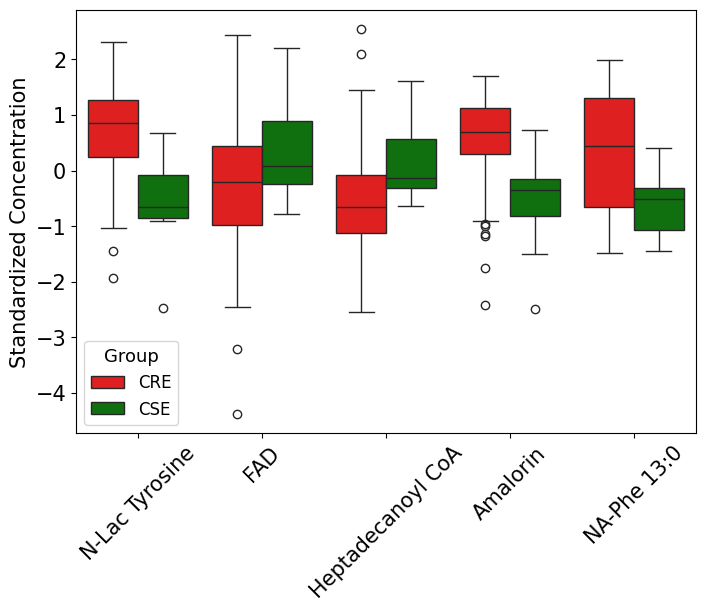

In [9]:
# Convert the wide-format data into long-format using pd.melt
df_long = pd.melt(annotated_mz_data[annotated_mz_data['Organism'] == "Klebsiella pneumoniae"].iloc[:, :513], 
                  id_vars=['Group'], 
                  var_name='m/z', 
                  value_name='Standardized_Value')

# Replace multiple m/z with annotations
df_long['m/z'] = df_long['m/z'].replace({'254.100118' : 'N-Lac Tyrosine', '786.1647168': 'FAD', '237.075651' : 'Amalorin', '1020.369159' : 'Heptadecanoyl CoA', '362.2677346' : 'NA-Phe 13:0'})


replacement_dict_kp = {'254.100118' : 'N-Lac Tyrosine', '786.1647168': 'FAD', '237.075651' : 'Amalorin', '1020.369159' : 'Heptadecanoyl CoA', '362.2677346' : 'NA-Phe 13:0'}
most_important_metabolites_l1_regularization_kp_renamed = [replacement_dict_kp.get(x, x) for x in feature_coeff_df_kp['Feature'].tolist()]  # Replace based on the dictionary

# Create the boxplot with the 'hue' separating the groups
plt.figure(figsize=(8, 5.5))
sns.boxplot(x='m/z', y='Standardized_Value', hue='Group', data=df_long[df_long['m/z'].isin(most_important_metabolites_l1_regularization_kp_renamed)], palette={'CRE': 'red', 'CSE': 'green'})
plt.xticks(rotation= 45, fontsize = 15)  # Apply the new labels and rotate them
plt.yticks(fontsize = 15)
plt.xlabel('')
plt.ylabel('Standardized Concentration', fontsize = 15)
plt.legend(title="Group", fontsize=12, title_fontsize='13')  # Set fontsize for legend and title

plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/boxplot_all_data_lasso_significant_cre_vs_cse_kp.png", bbox_inches = 'tight')
plt.savefig('C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/boxplot_all_data_lasso_significant_cre_vs_cse_kp.tiff', format='tiff', dpi=300, bbox_inches="tight")


# Ecoli

C:\Users\nicky\AppData\Local\Temp\ipykernel_504\815868541.py:54: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  precisions_ecoli.append(interp(mean_recall_ecoli, recall_ecoli[::-1], precision_ecoli[::-1]))  # Reverse precision and recall
C:\Users\nicky\AppData\Local\Temp\ipykernel_504\815868541.py:77: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs_ecoli.append(interp(mean_fpr_ecoli, fpr_ecoli, tpr_ecoli))  # Interpolate TPRs at common FPR points
C:\Users\nicky\AppData\Local\Temp\ipykernel_504\815868541.py:54: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  precisions_ecoli.append(interp(mean_recall_ecoli, recall_ecoli[::-1], precision_ecoli[::-1]))  # Reverse precision and recall
C:\Users\nicky\AppData\Local\Temp\ipykernel_504\815868541.py:77: DeprecationWarning: scipy.interp is deprecated and wi

AUC: Mean = 0.6763, Std = 0.1058
AUPRC: Mean = 0.6594, Std = 0.1100
Sensitivity: Mean = 0.4792, Std = 0.1887
Specificity: Mean = 0.7590, Std = 0.1382
PPV: Mean = 0.6102, Std = 0.1826
NPV: Mean = 0.6529, Std = 0.0819
Accuracy: Mean = 0.6346, Std = 0.0883


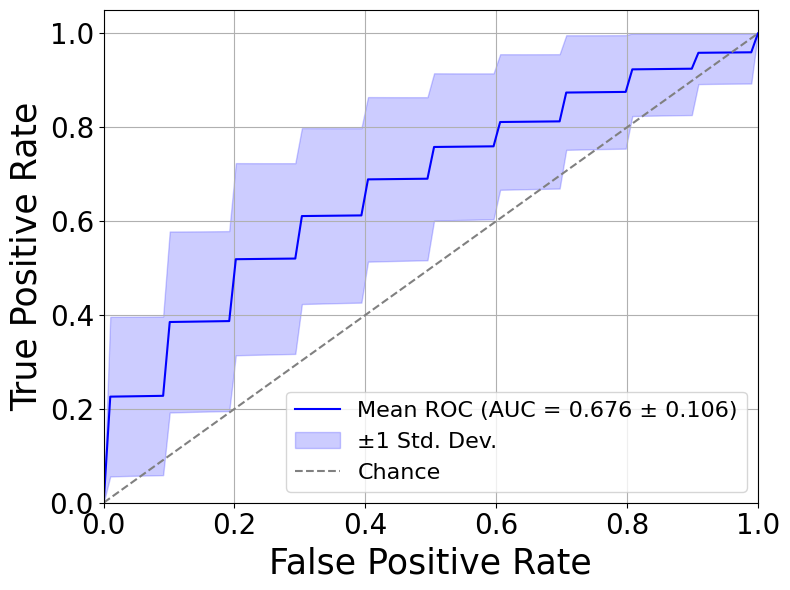

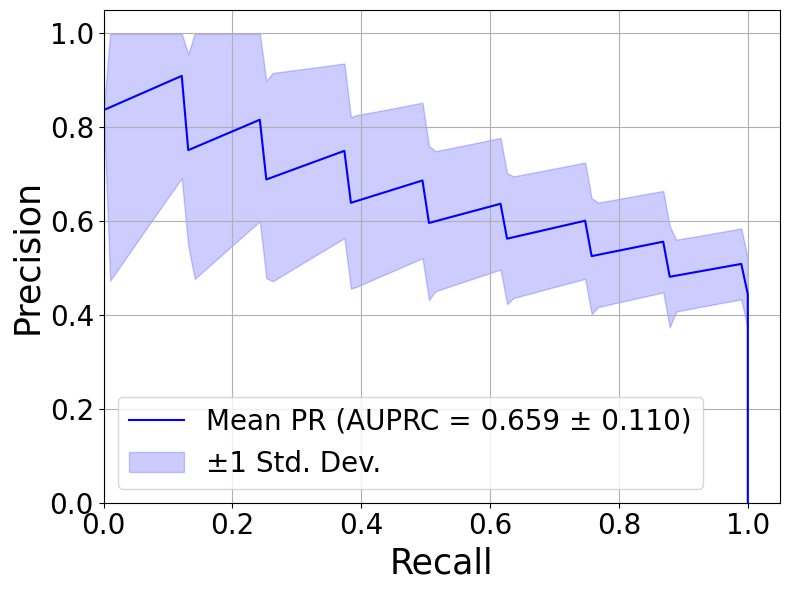

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LassoCV
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, confusion_matrix, accuracy_score
import time

start = time.time()

# Assuming your data is in X (features) and y (labels)
X_ecoli = ecoli_data.iloc[:, :len(ecoli_data.columns) - 4] # Feature data
y_ecoli = pd.Series(np.where(ecoli_data['Group'] == 'CRE', 1, 0)) # phenotype data

# For ROC curve plotting
tprs_ecoli = []  # Store TPR values (true positive rates) for each split
aucs_ecoli = []  # Store AUC values for each split
mean_fpr_ecoli = np.linspace(0, 1, 100)  # Common FPR points for interpolation

# For Precision-Recall curve plotting
precisions_ecoli = []  # Store interpolated precision values for each split
mean_recall_ecoli = np.linspace(0, 1, 100)  # Common recall points for interpolation
auprcs_ecoli = []  # Store AUPRC values for each split

# To store all metrics
results_ecoli = {
    'AUC': [],
    'AUPRC': [],
    'Sensitivity': [],
    'Specificity': [],
    'PPV': [],
    'NPV': [],
    'Accuracy': []
}

for i in range(300):
    # 80/20 train-test split
    X_train_ecoli, X_test_ecoli, y_train_ecoli, y_test_ecoli = train_test_split(X_ecoli, y_ecoli, test_size=0.2, stratify=y_ecoli, random_state=i)

    # 5-fold LassoCV on training set
    lasso_cv_ecoli = LassoCV(cv=5, max_iter=5000).fit(X_train_ecoli, y_train_ecoli)
    
    # Predict probabilities on test set
    y_pred_proba_ecoli = lasso_cv_ecoli.predict(X_test_ecoli)
    y_pred_ecoli = np.where(y_pred_proba_ecoli > 0.5, 1, 0)
    
    # Calculate AUC
    auc_score_ecoli = roc_auc_score(y_test_ecoli, y_pred_proba_ecoli)
    
    # Calculate AUPRC (Area Under Precision-Recall Curve)
    precision_ecoli, recall_ecoli, _ = precision_recall_curve(y_test_ecoli, y_pred_proba_ecoli)
    auprc_score_ecoli = auc(recall_ecoli, precision_ecoli)
    
    # Interpolate precision values to common recall points
    precisions_ecoli.append(interp(mean_recall_ecoli, recall_ecoli[::-1], precision_ecoli[::-1]))  # Reverse precision and recall
    auprcs_ecoli.append(auprc_score_ecoli)
    
    # Confusion matrix metrics
    tn_ecoli, fp_ecoli, fn_ecoli, tp_ecoli = confusion_matrix(y_test_ecoli, y_pred_ecoli).ravel()
    
    sensitivity_ecoli = tp_ecoli / (tp_ecoli + fn_ecoli)  # Recall
    specificity_ecoli = tn_ecoli / (tn_ecoli + fp_ecoli)
    ppv_ecoli = tp_ecoli / (tp_ecoli + fp_ecoli) if tp_ecoli + fp_ecoli > 0 else 0  # Precision
    npv_ecoli = tn_ecoli / (tn_ecoli + fn_ecoli) if tn_ecoli + fn_ecoli > 0 else 0
    accuracy_ecoli = accuracy_score(y_test_ecoli, y_pred_ecoli)

    # Append to results
    results_ecoli['AUC'].append(auc_score_ecoli)
    results_ecoli['AUPRC'].append(auprc_score_ecoli)
    results_ecoli['Sensitivity'].append(sensitivity_ecoli)
    results_ecoli['Specificity'].append(specificity_ecoli)
    results_ecoli['PPV'].append(ppv_ecoli)
    results_ecoli['NPV'].append(npv_ecoli)
    results_ecoli['Accuracy'].append(accuracy_ecoli)
    
    # ROC curve calculation
    fpr_ecoli, tpr_ecoli, _ = roc_curve(y_test_ecoli, y_pred_proba_ecoli)
    tprs_ecoli.append(interp(mean_fpr_ecoli, fpr_ecoli, tpr_ecoli))  # Interpolate TPRs at common FPR points
    tprs_ecoli[-1][0] = 0.0  # Ensure TPR starts at 0
    aucs_ecoli.append(auc_score_ecoli)  # Store AUC for this split
    
final_results_ecoli = {metric_ecoli: {'mean': np.mean(values_ecoli), 'std': np.std(values_ecoli)} for metric_ecoli, values_ecoli in results_ecoli.items()}
# Display final results
for metric_ecoli, stats_ecoli in final_results_ecoli.items():
    print(f"{metric_ecoli}: Mean = {stats_ecoli['mean']:.4f}, Std = {stats_ecoli['std']:.4f}")
    
# Step 5: Compute the average ROC curve and plot with ±1 standard deviation
mean_tpr_ecoli = np.mean(tprs_ecoli, axis=0)
mean_tpr_ecoli[-1] = 1.0  # Ensure the last TPR is 1
mean_auc_ecoli = np.mean(aucs_ecoli)
std_auc_ecoli = np.std(aucs_ecoli)
std_tpr_ecoli = np.std(tprs_ecoli, axis=0)

# Step 6: Compute the average PR curve and plot with ±1 standard deviation
mean_precision_ecoli = np.mean(precisions_ecoli, axis=0)
mean_auprc_ecoli = np.mean(auprcs_ecoli)
std_auprc_ecoli = np.std(auprcs_ecoli)
std_precision_ecoli = np.std(precisions_ecoli, axis=0)

plt.figure(figsize=(8, 6))

plt.plot(mean_fpr_ecoli, mean_tpr_ecoli, color='b', label=r'Mean ROC (AUC = {:.3f} ± {:.3f})'.format(mean_auc_ecoli, std_auc_ecoli))

# Plot the standard deviation as a shaded area
tpr_upper_ecoli = np.minimum(mean_tpr_ecoli + std_tpr_ecoli, 1)
tpr_lower_ecoli = np.maximum(mean_tpr_ecoli - std_tpr_ecoli, 0)
plt.fill_between(mean_fpr_ecoli, tpr_lower_ecoli, tpr_upper_ecoli, color='b', alpha=0.2, label=r'±1 Std. Dev.')

# Add labels and titles
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.xlabel('False Positive Rate', fontsize = 25)
plt.ylabel('True Positive Rate', fontsize = 25)
plt.legend(loc="lower right", fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/roc_curve_with_mean_and_std_cre_vs_cse_ecoli.png", bbox_inches = 'tight')

# Show the plot
plt.show()

# Add value to be in plot at (1, 0)
mean_recall_ecoli = np.append(mean_recall_ecoli, 1)
mean_precision_ecoli = np.append(mean_precision_ecoli, 0)
# Add value to std
std_precision_ecoli = np.insert(std_precision_ecoli, 0, 0)

plt.figure(figsize=(8, 6))

# Plot for Precision-Recall Curve
plt.plot(mean_recall_ecoli, mean_precision_ecoli, color='b', label=r'Mean PR (AUPRC = {:.3f} ± {:.3f})'.format(mean_auprc_ecoli, std_auprc_ecoli))

# Plot the standard deviation as a shaded area for Precision-Recall
precision_upper_ecoli = np.minimum(mean_precision_ecoli + std_precision_ecoli, 1)
precision_lower_ecoli = np.maximum(mean_precision_ecoli - std_precision_ecoli, 0)
plt.fill_between(mean_recall_ecoli, precision_lower_ecoli, precision_upper_ecoli, color='b', alpha=0.2, label=r'±1 Std. Dev.')

# Add labels and titles for PR
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.xlabel('Recall', fontsize = 25)
plt.ylabel('Precision', fontsize = 25)
plt.legend(loc="lower left", fontsize=20)
plt.grid(True)
# Show the plot
plt.tight_layout()
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/auprc_curve_with_mean_and_std_cre_vs_cse_ecoli.png", bbox_inches = 'tight')

plt.show()

In [ ]:
final_results_ecoli

{'AUC': {'mean': 0.6763125, 'std': 0.10582745021377961},
 'AUPRC': {'mean': 0.6594460670048905, 'std': 0.11003946144720966},
 'Sensitivity': {'mean': 0.4791666666666667, 'std': 0.18869986457040422},
 'Specificity': {'mean': 0.759, 'std': 0.1381508836984645},
 'PPV': {'mean': 0.6101848244348244, 'std': 0.18256644093131144},
 'NPV': {'mean': 0.6529281736781737, 'std': 0.08194754325695022},
 'Accuracy': {'mean': 0.6346296296296298, 'std': 0.08826381300324077}}

### Fitting on all data to see what biomarkers remain 

In [10]:
# Feature names (column names of the DataFrame)
feature_names_ecoli = ecoli_data.iloc[:, :len(ecoli_data.columns) - 4].columns

# 5-fold LassoCV on training set
lasso_cv_ecoli_all_data = LassoCV(cv=5, max_iter = 5000).fit(ecoli_data.iloc[:, :len(ecoli_data.columns) - 4], pd.Series(np.where(ecoli_data['Group'] == 'CRE', 1, 0)))

# Step 4: Get the coefficients after Lasso regularization
lasso_coefficients_ecoli_all_data = lasso_cv_ecoli_all_data.coef_

# Step 5: Find the features with non-zero coefficients
# Step 5: Create a DataFrame for non-zero coefficients
# Filter out the features with non-zero coefficients
remaining_features_ecoli = feature_names_ecoli[lasso_coefficients_ecoli_all_data != 0]
remaining_coefficients_ecoli = lasso_coefficients_ecoli_all_data[lasso_coefficients_ecoli_all_data != 0]

# Create a DataFrame with the selected features and their corresponding beta coefficients
feature_coeff_df_ecoli = pd.DataFrame({
    'Feature': remaining_features_ecoli,
    'Beta Coefficient': remaining_coefficients_ecoli
})

feature_coeff_df_ecoli

,Feature,Beta Coefficient
0,576.3496399,-0.014215
1,242.1859893,-0.045922
2,549.2586929,-0.007711
3,302.3066591,0.021613
4,318.3026049,0.005243
5,467.2421198,0.008073


Below we create the boxplots for the remaining metabolites from the lasso model for E. Coli.

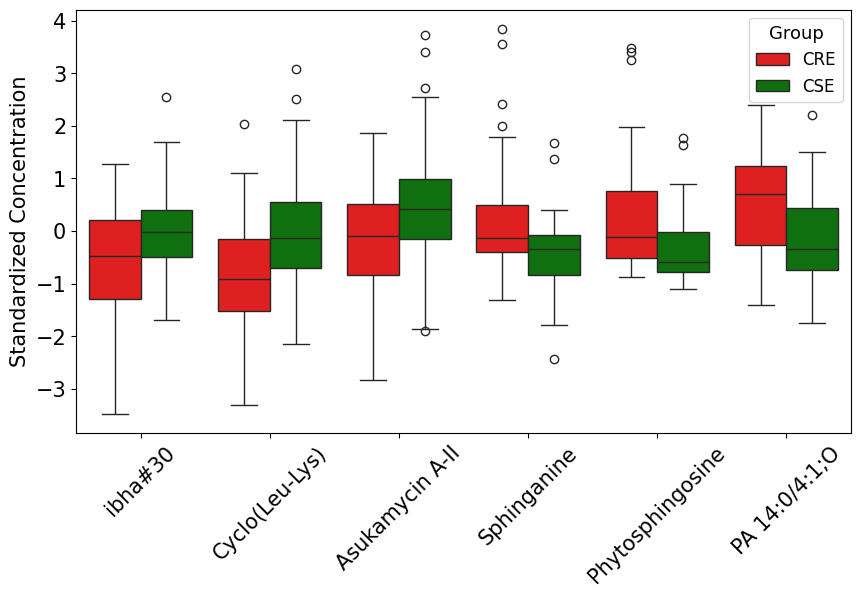

In [11]:
# Convert the wide-format data into long-format using pd.melt()
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert the wide-format data into long-format using pd.melt
df_long_ecoli = pd.melt(annotated_mz_data[annotated_mz_data['Organism'] == "Escherichia coli"].iloc[:, :513], 
                  id_vars=['Group'], 
                  var_name='m/z', 
                  value_name='Standardized_Value')

# Replace multiple m/z with annotations
df_long_ecoli['m/z'] = df_long_ecoli['m/z'].replace({'576.3496399' : 'ibha#30', '242.1859893' : 'Cyclo(Leu-Lys)', '549.2586929' : 'Asukamycin A-II', 
                          '302.3066591' : 'Sphinganine', '318.3026049': 'Phytosphingosine', '467.2421198' : 'PA 14:0/4:1;O'})

replacement_dict_ecoli = {'576.3496399' : 'ibha#30', '242.1859893' : 'Cyclo(Leu-Lys)', '549.2586929' : 'Asukamycin A-II', 
                          '302.3066591' : 'Sphinganine', '318.3026049': 'Phytosphingosine', '467.2421198' : 'PA 14:0/4:1;O'}
most_important_metabolites_l1_regularization_ecoli_renamed = [replacement_dict_ecoli.get(x, x) for x in feature_coeff_df_ecoli['Feature'].tolist()]  # Replace based on the dictionary

# Create the boxplot with the 'hue' separating the groups
plt.figure(figsize=(10, 5.5))
sns.boxplot(x='m/z', y='Standardized_Value', hue='Group', data=df_long_ecoli[df_long_ecoli['m/z'].isin(most_important_metabolites_l1_regularization_ecoli_renamed)], palette={'CRE': 'red', 'CSE': 'green'})

# Customize x-axis tick labels
#new_xticklabels = ['1-acetoxy-N-salicyloyl-2-aminopropan-3-ol', 'N-Acetyl-3,4-dihydroxy-L-phenylalanine', 
 #                  'N-Butyryl-L-homoserine lactone', 'Amalorin']  # Replace with your new labels

plt.xticks(rotation=45, fontsize = 15)  # Apply the new labels and rotate them
plt.yticks(fontsize = 15)
plt.xlabel('')
plt.ylabel('Standardized Concentration', fontsize = 15)
plt.legend(title="Group", fontsize=12, title_fontsize='13')  # Set fontsize for legend and title

# Add the title with italicized 'Klebsiella pneumoniae'
#plt.title('$Klebsiella$ $pneumoniae$ Significant Metabolites')
    
# Plot significance stars
#plt.text(0.03, y_max - 2.3, '*', ha='center', va='bottom', color='red', fontsize=15)
#plt.text(1.03, y_max - 2.3, '*', ha='center', va='bottom', color='red', fontsize=15)
#plt.text(2.03, y_max - 2.3, '*', ha='center', va='bottom', color='red', fontsize=15)
#plt.text(3.03, y_max - 2.3, '**', ha='center', va='bottom', color='red', fontsize=15)
#plt.text(4.03, y_max - 2.3, '*', ha='center', va='bottom', color='red', fontsize=15)
#plt.text(5.03, y_max - 2.3, '*', ha='center', va='bottom', color='red', fontsize=15)
#plt.text(6.03, y_max - 2.3, '*', ha='center', va='bottom', color='red', fontsize=15)
#plt.text(7.03, y_max - 2.3, '*', ha='center', va='bottom', color='red', fontsize=15)

plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/boxplot_all_data_lasso_significant_cre_vs_cse_ecoli.png", bbox_inches = 'tight')
plt.savefig('C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/boxplot_all_data_lasso_significant_cre_vs_cse_ecoli.tiff', format='tiff', dpi=300, bbox_inches="tight")
